## Setup

In [17]:
from src.phrase_analysis import process_directory, plot_phrase_frequency_over_time_all, plot_length_distribution, analyze_files_phrase_occurrences, get_recent_contexts_all, get_per_appearance_frequency, calculate_poisson_predictions, calculate_negative_binomial_predictions, format_prediction_table, get_phrases, process_json
from src.regex_pattern_generator import generate_regex_patterns
from datetime import datetime
import pandas as pd

In [18]:
PHRASES = get_phrases("KXNFLMENTION-26JAN10GBCHI") + ['Grass'] + ["Al", "Michaels", "Kirk", "Herbstreit", "Fan voting"]
PHRASES = ['Robert Kraft / Robert Craft' if phrase == 'Robert Kraft' else phrase for phrase in PHRASES]
PHRASES = ['JJ Watt / J.J. Watt / J.J Watt' if phrase == 'JJ Watt' else phrase for phrase in PHRASES]
SEARCH_PHRASES = generate_regex_patterns(PHRASES)
SEARCH_PHRASES['Tie'] = "\\b(?:\\w+-)*(?:tie)(?:-\\w+)*(?=\\W|$)[.,!?;:]*"
from pprint import pprint
pprint(SEARCH_PHRASES)

away = 'packers'
home = 'bears'


{'Al': "\\b(?:\\w+-)*(?:al|als|al's|als')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Contract': "\\b(?:\\w+-)*(?:contract|contracts|contract's|contracts')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Fan voting': "\\b(?:\\w+-)*(?:fan[\\s,\\-]+voting|fan[\\s,\\-]+votings|fan[\\s,\\-]+voting's|fan[\\s,\\-]+votings'|fans[\\s,\\-]+voting|fans[\\s,\\-]+votings|fans[\\s,\\-]+voting's|fans[\\s,\\-]+votings'|fan's[\\s,\\-]+voting|fan's[\\s,\\-]+votings|fan's[\\s,\\-]+voting's|fan's[\\s,\\-]+votings'|fans'[\\s,\\-]+voting|fans'[\\s,\\-]+votings|fans'[\\s,\\-]+voting's|fans'[\\s,\\-]+votings')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Fine / Fines / Fined': "\\b(?:\\w+-)*(?:(?:fine|fines|fine's|fines'|fines|fine|fines's|finess'|fine'|fined|fineds|fined's|fineds'))(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Grass': "\\b(?:\\w+-)*(?:grass|grasses|grass's|grasss'|grasses')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Herbstreit': "\\b(?:\\w+-)*(?:herbstreit|herbstreits|herbstreit's|herbstreits')(?:-\\w+)*(?=\\W|$)[.,!?;:]*",
 'Hunt / Hunting': "\\b(?:\\w+

In [19]:
# Process transcripts

df_mnf = process_directory('../data-football/nfl/mnf/transcripts', SEARCH_PHRASES)
df_snf = process_directory('../data-football/nfl/snf/transcripts', SEARCH_PHRASES)
df_tnf = process_directory('../data-football/nfl/tnf/transcripts', SEARCH_PHRASES)

df_combined = pd.concat([df_mnf, df_snf, df_tnf])


df = df_tnf

# Print dataset statistics
print("Dataset Statistics:")

print(f"\nAll Transcripts:")
print(f"Total: {len(df)}")

print("\nWord Count Statistics:")

print(f"\nAll Transcripts:")
print(f"Average length: {df['text_length'].mean():.0f} words") 


print("\nDate Ranges:")

print(f"\nAll Transcripts:")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")

df_combined = pd.concat([df_mnf, df_snf, df_tnf])


KeyboardInterrupt: 

Expected length from category data: 18745 words


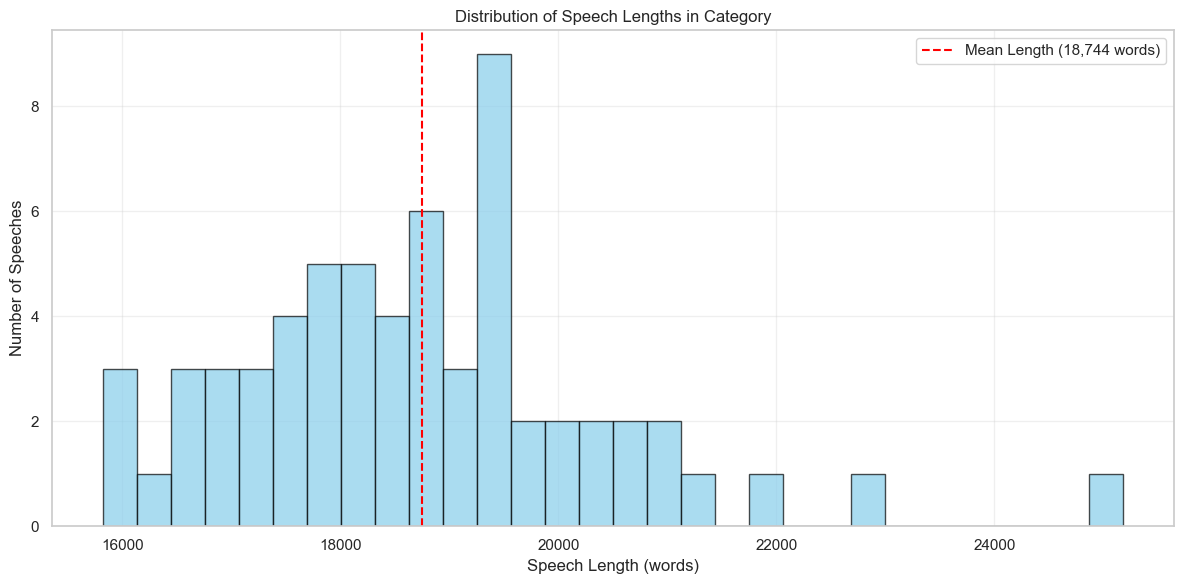

5 shortest transcripts by word count:


,file,date,text_length
45,2024-12-26_seahawks-at-bears.txt,2024-12-26,15826
20,2023-10-12_broncos-at-chiefs.txt,2023-10-12,16060
37,2022-10-13_commanders-at-bears.txt,2022-10-13,16137
17,2022-12-01_bills-at-patriots.txt,2022-12-01,16331
25,2025-12-25_broncos-at-chiefs.txt,2025-12-25,16630


In [20]:
plot_length_distribution(df)
# Print the 5 shortest transcripts by word count
print("5 shortest transcripts by word count:")
display(df.nsmallest(5, 'text_length')[['file', 'date', 'text_length']])


In [ ]:
# df_nfl = process_json('../data-football/older-games/nfl.json', SEARCH_PHRASES)
# df_nfl = df_nfl.sort_values('date')
# len(df_nfl)

In [ ]:
# nfl_recent = df_nfl[df_nfl['date'] > datetime(2015, 1, 1)]
# len(nfl_recent)

## Phrase Frequency Over Time

Speeches dropped off dramatically between election day and inauguration day. Non-speech transcripts mostly don't go back as far in time (need to scrape more data)


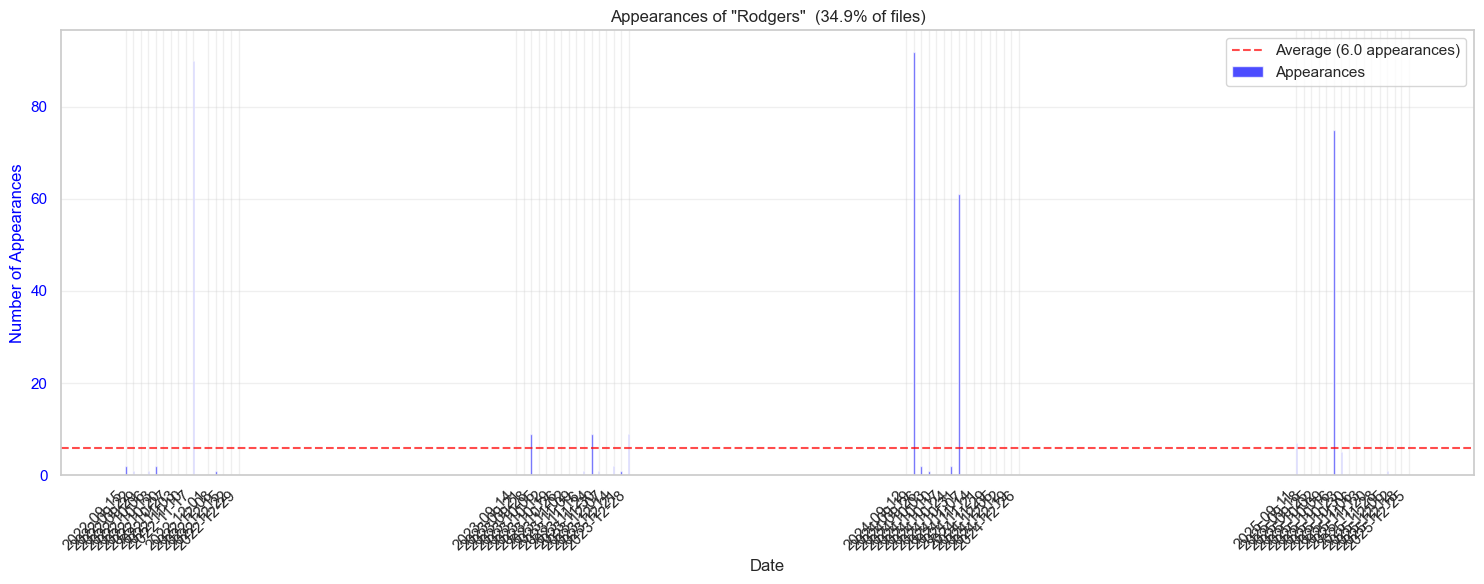


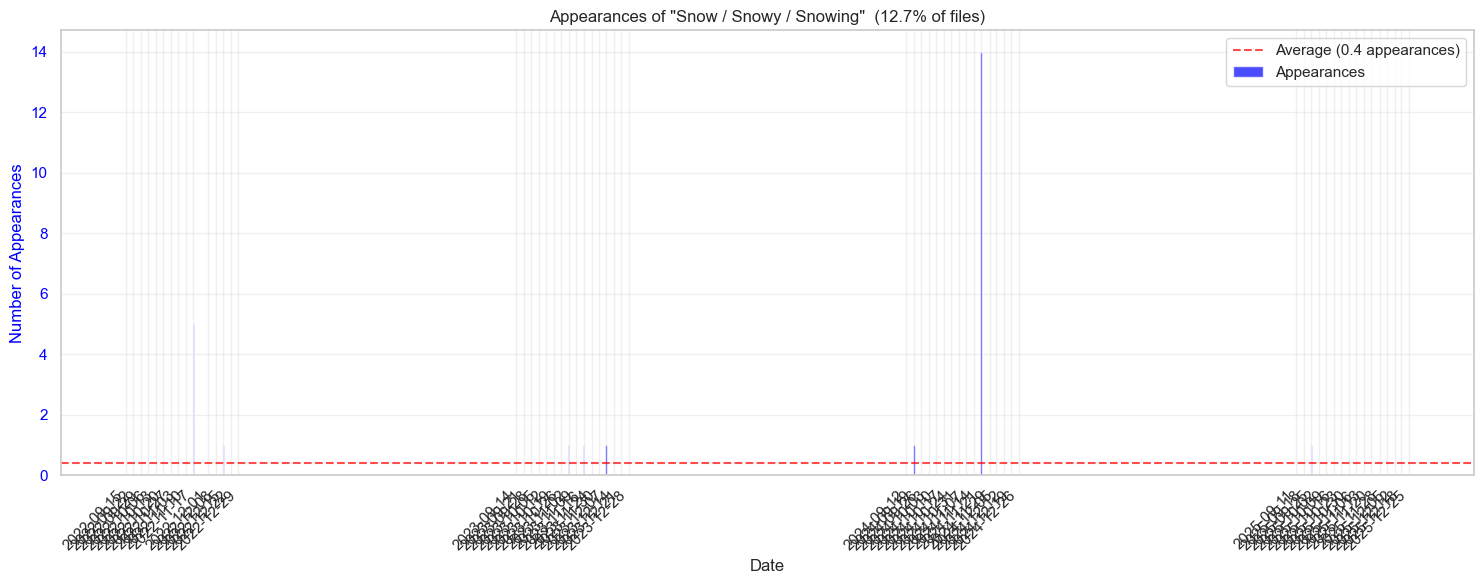


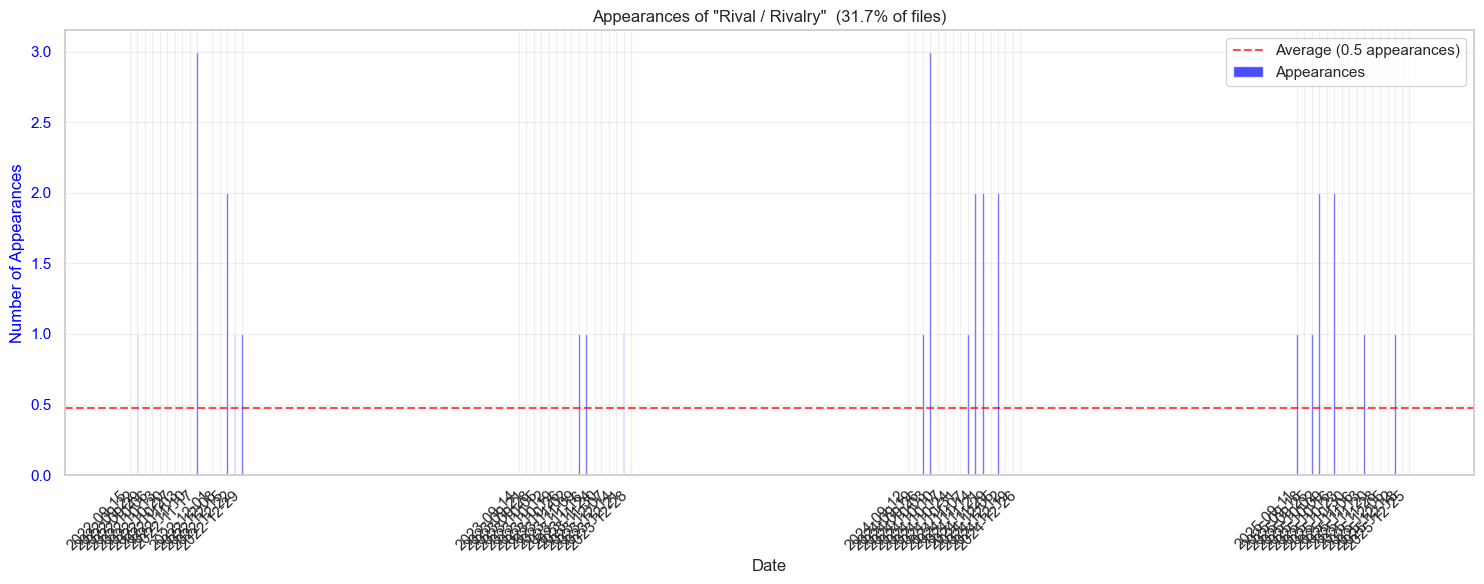


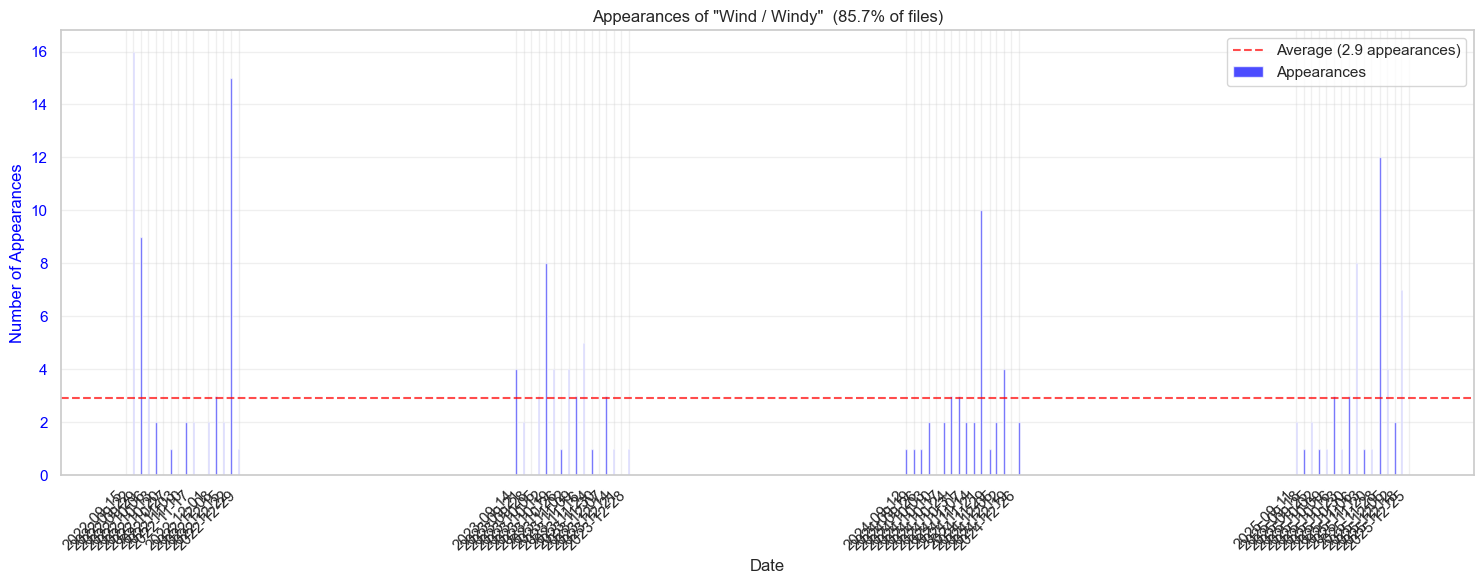


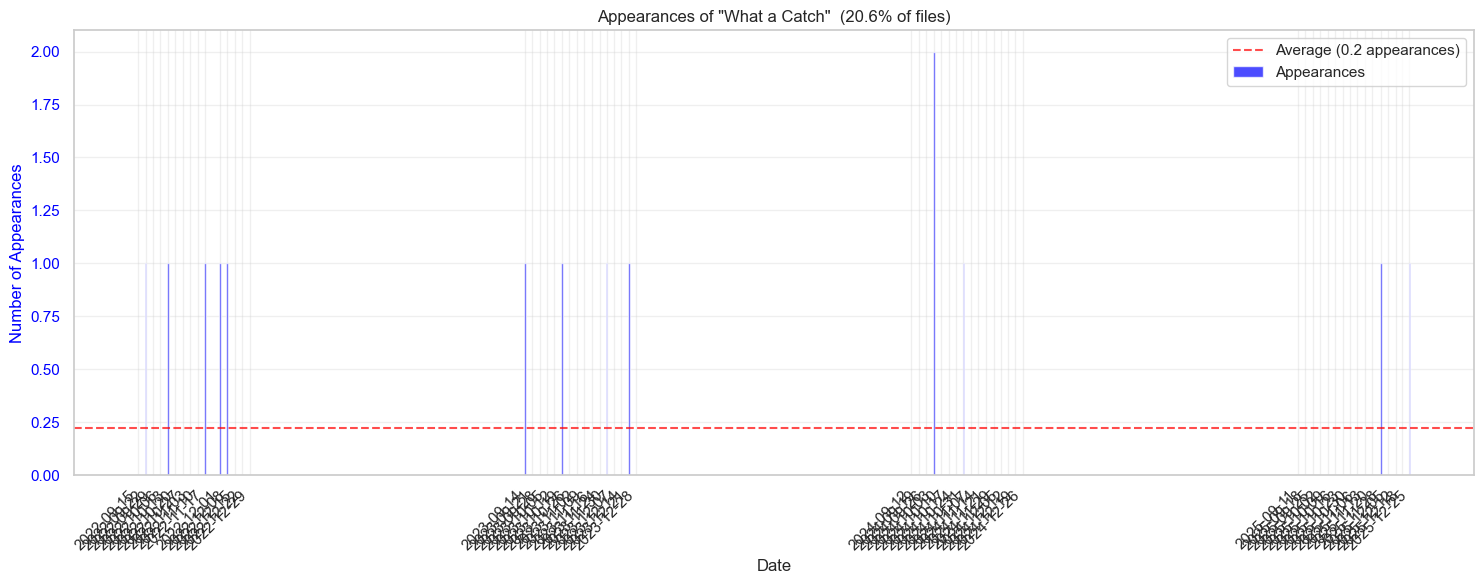


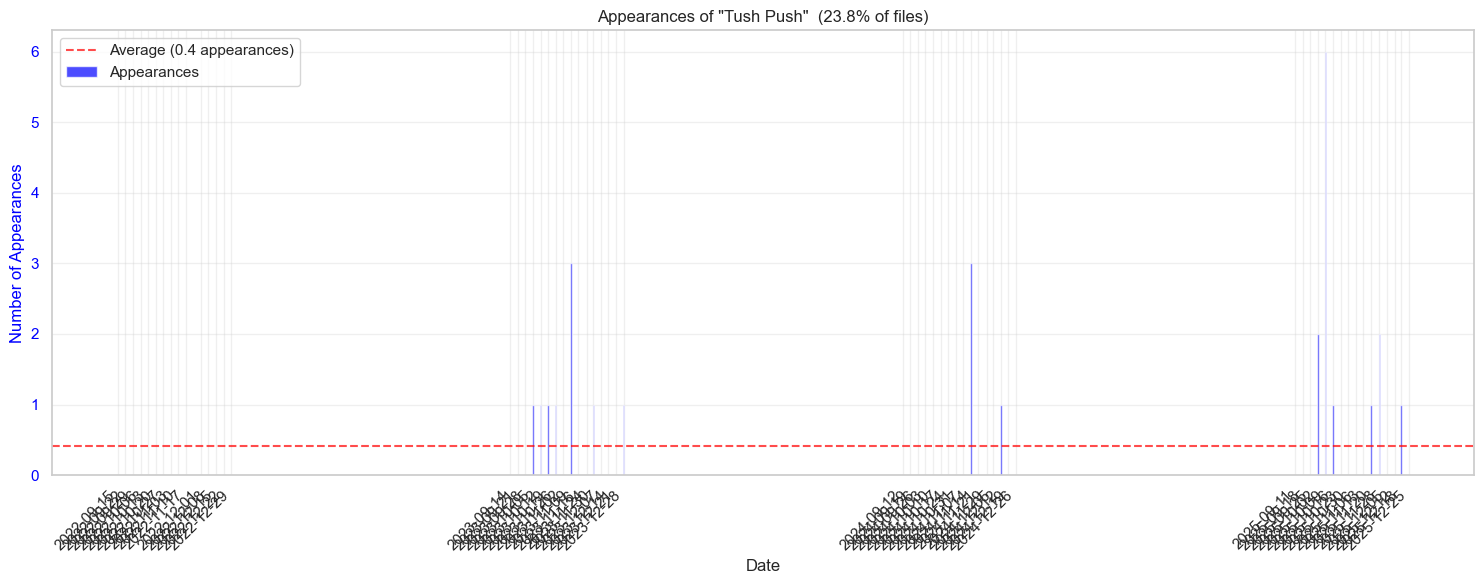


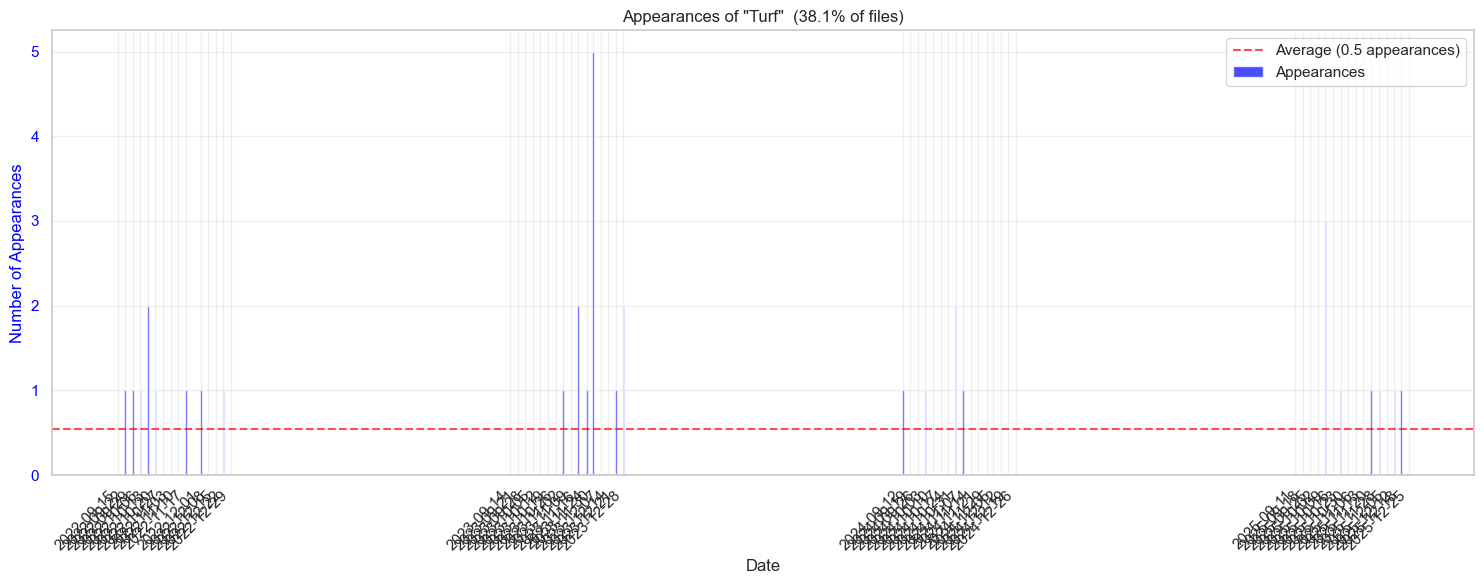


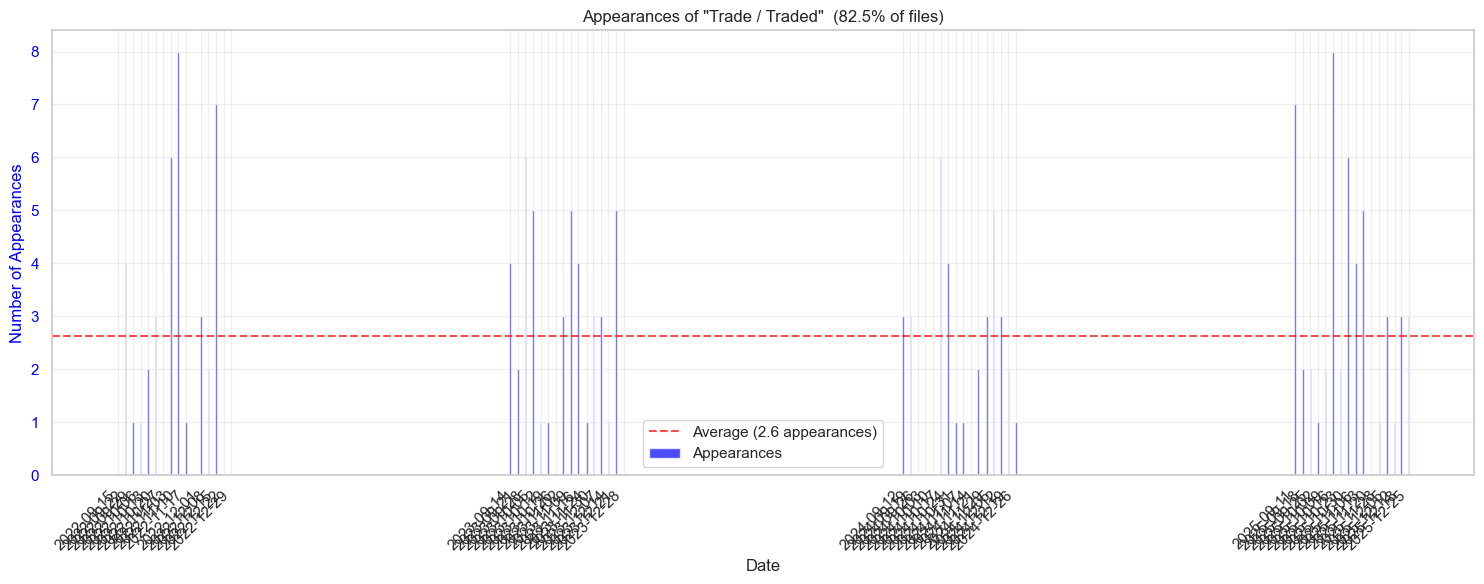


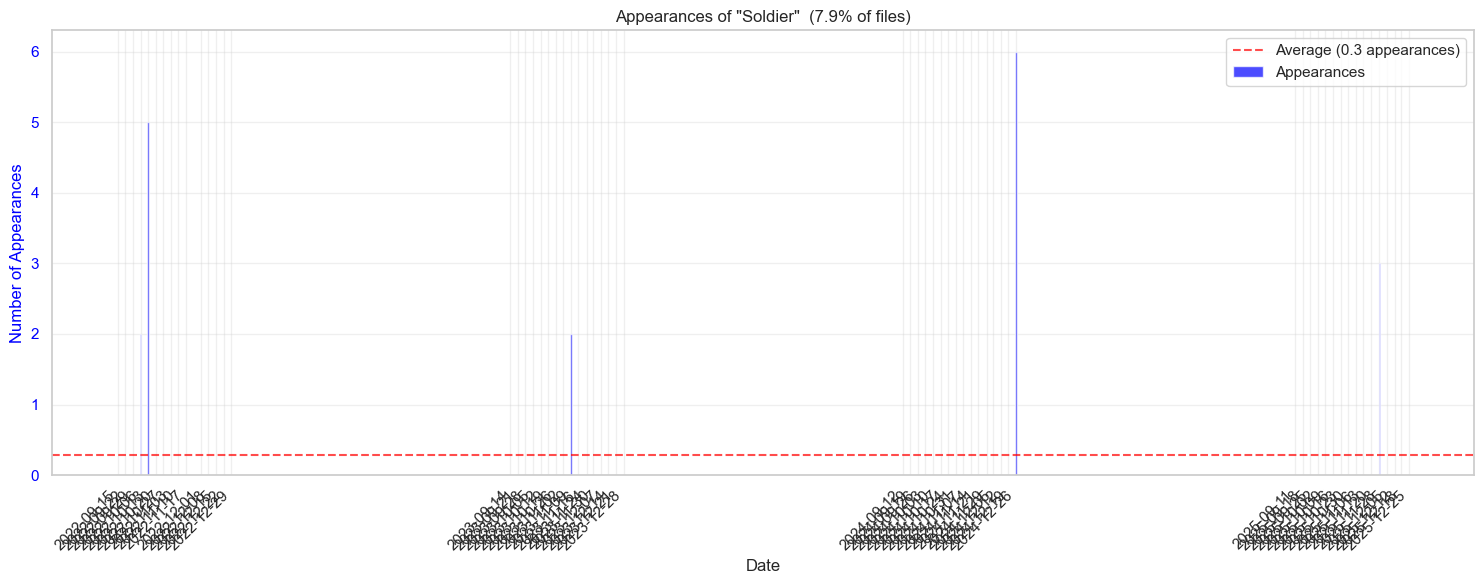


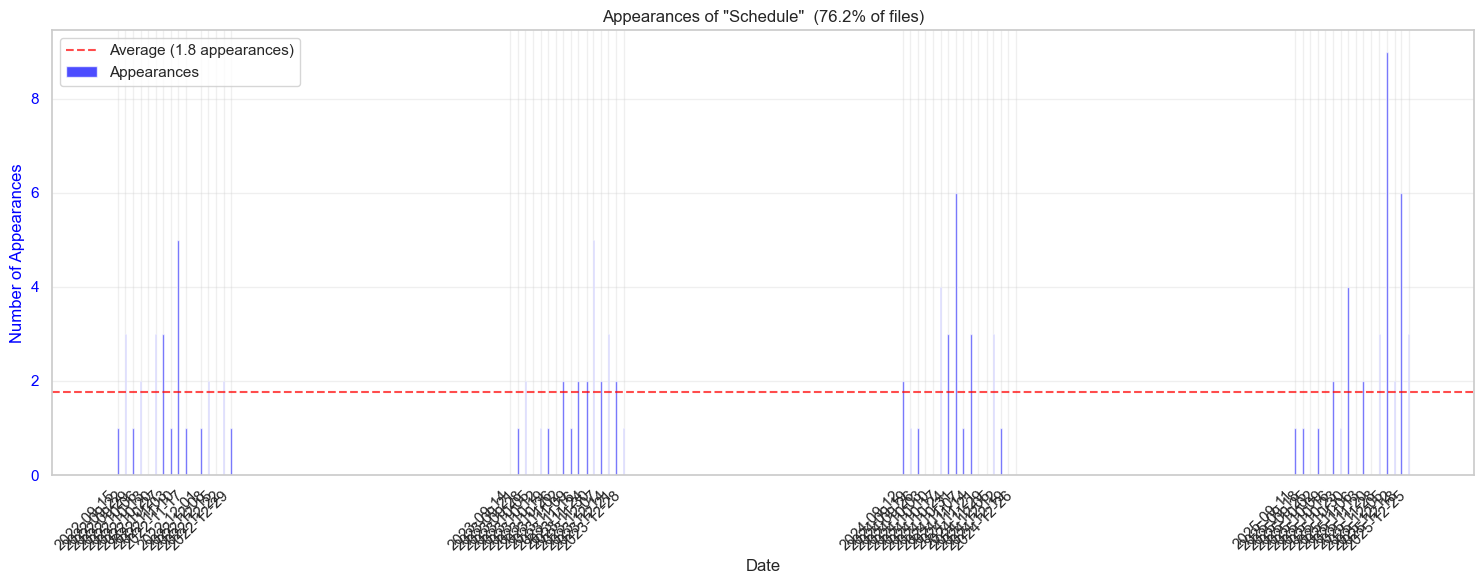


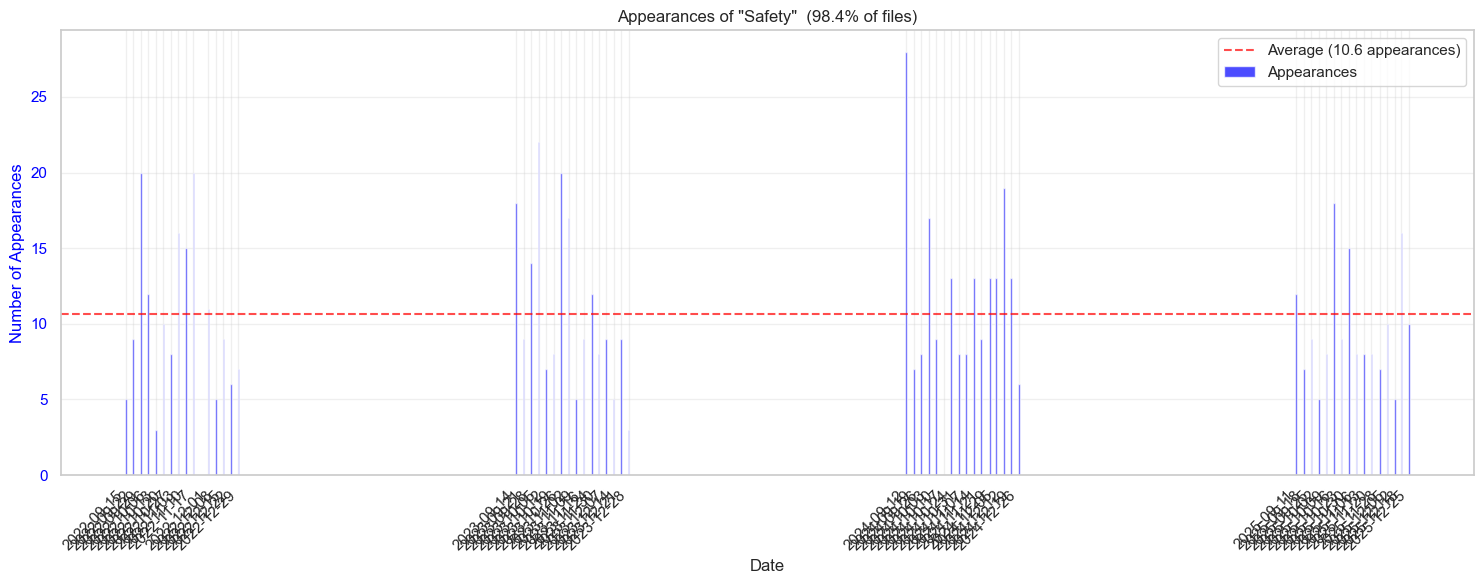


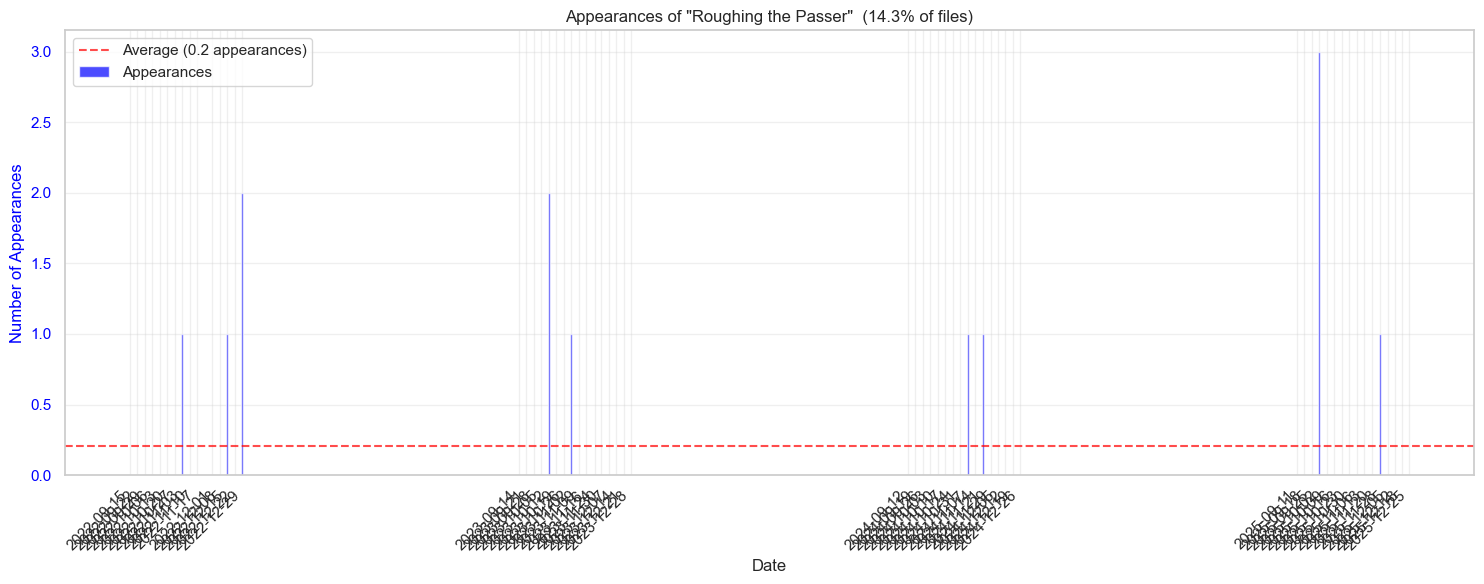


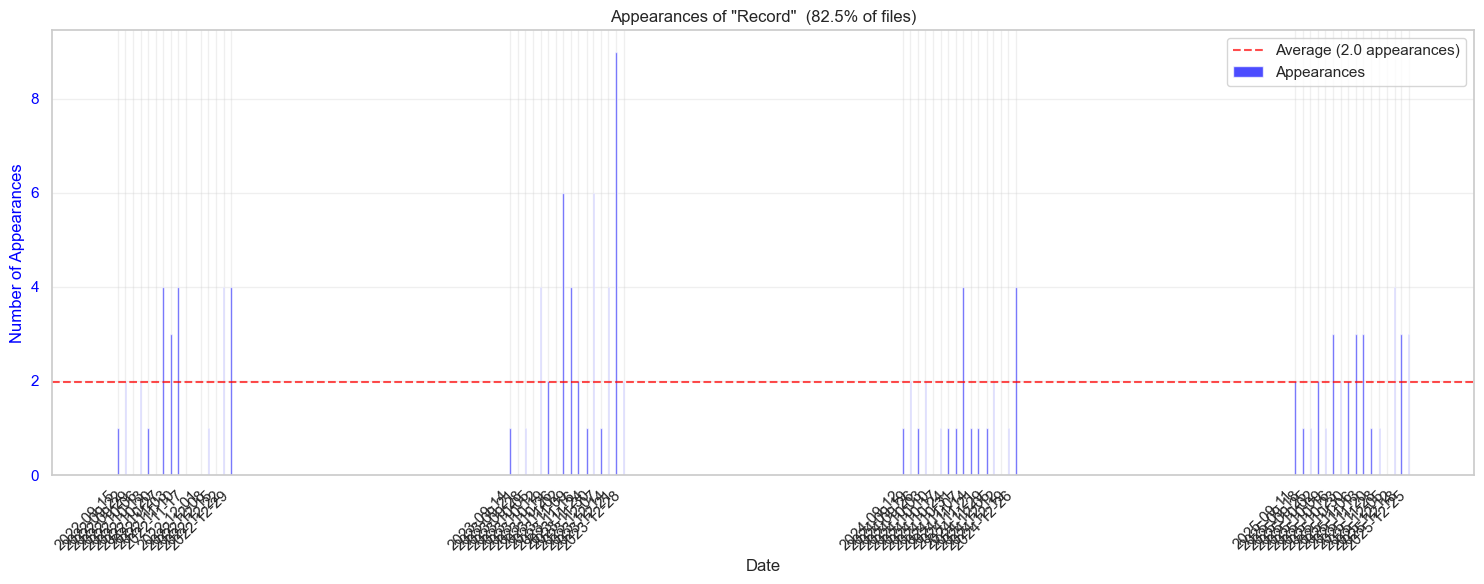


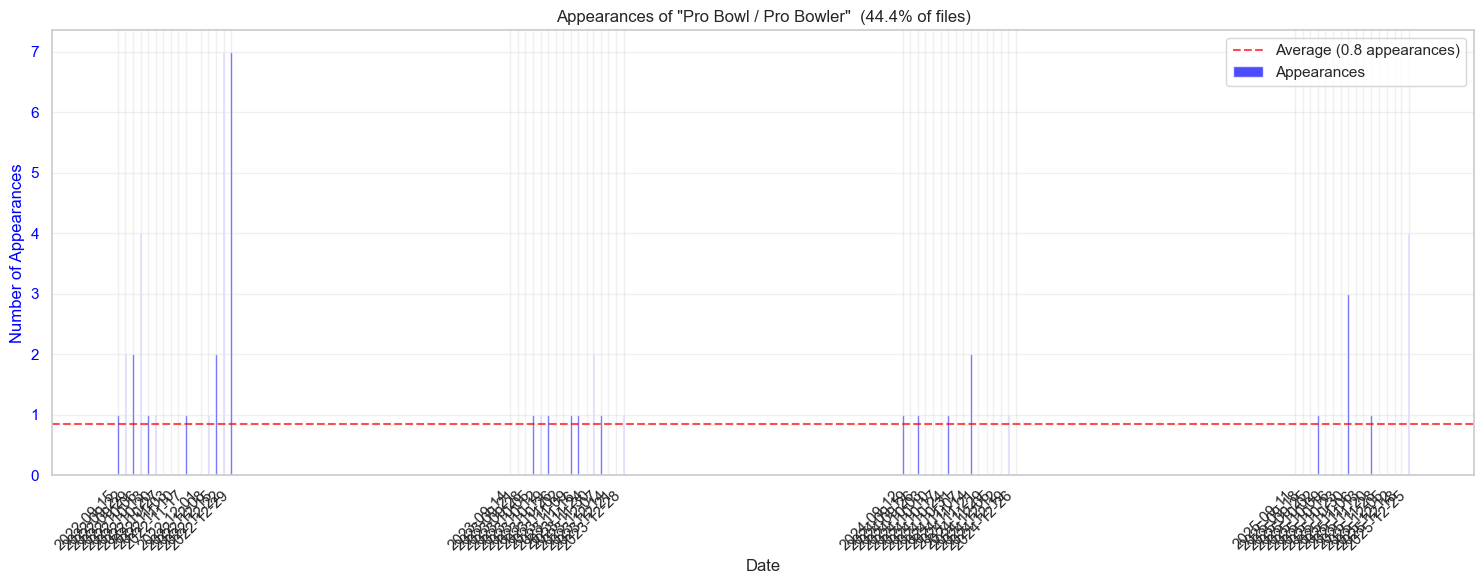


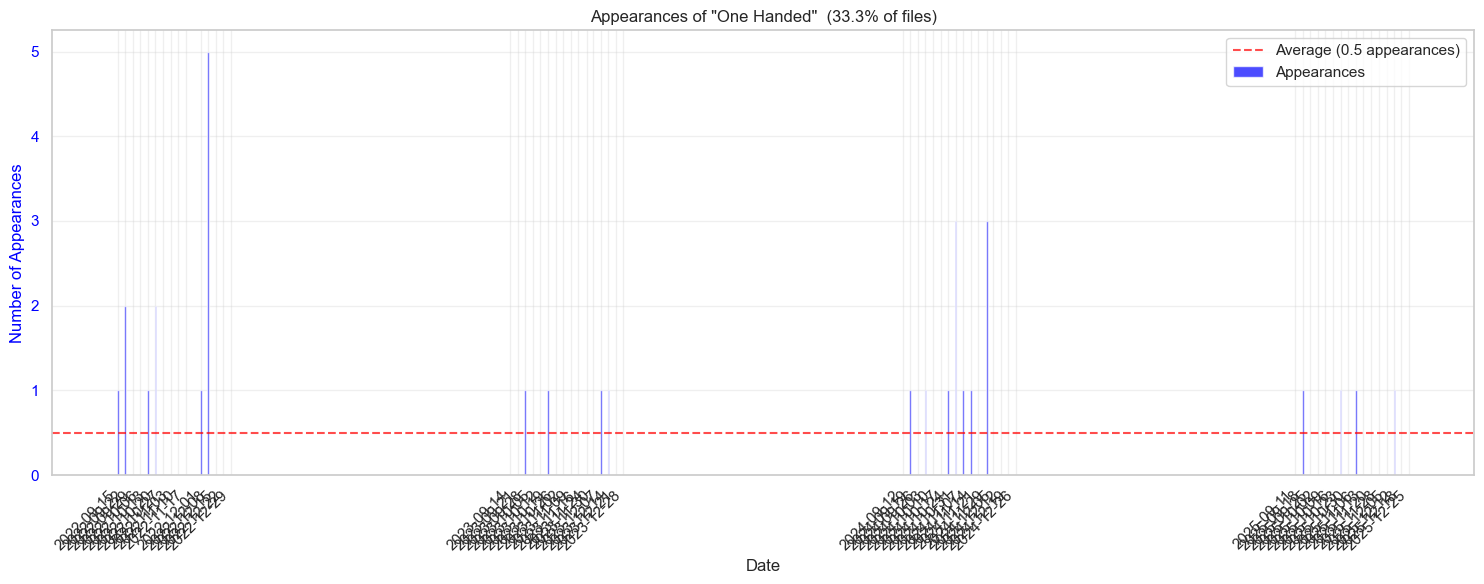


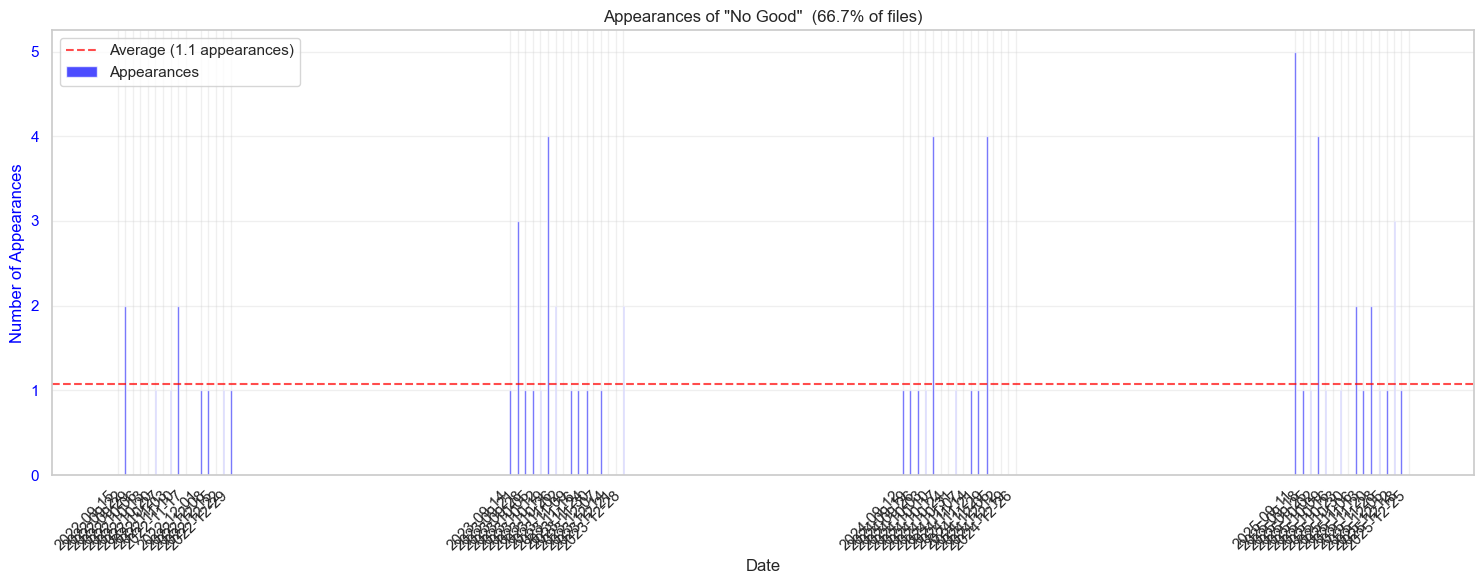


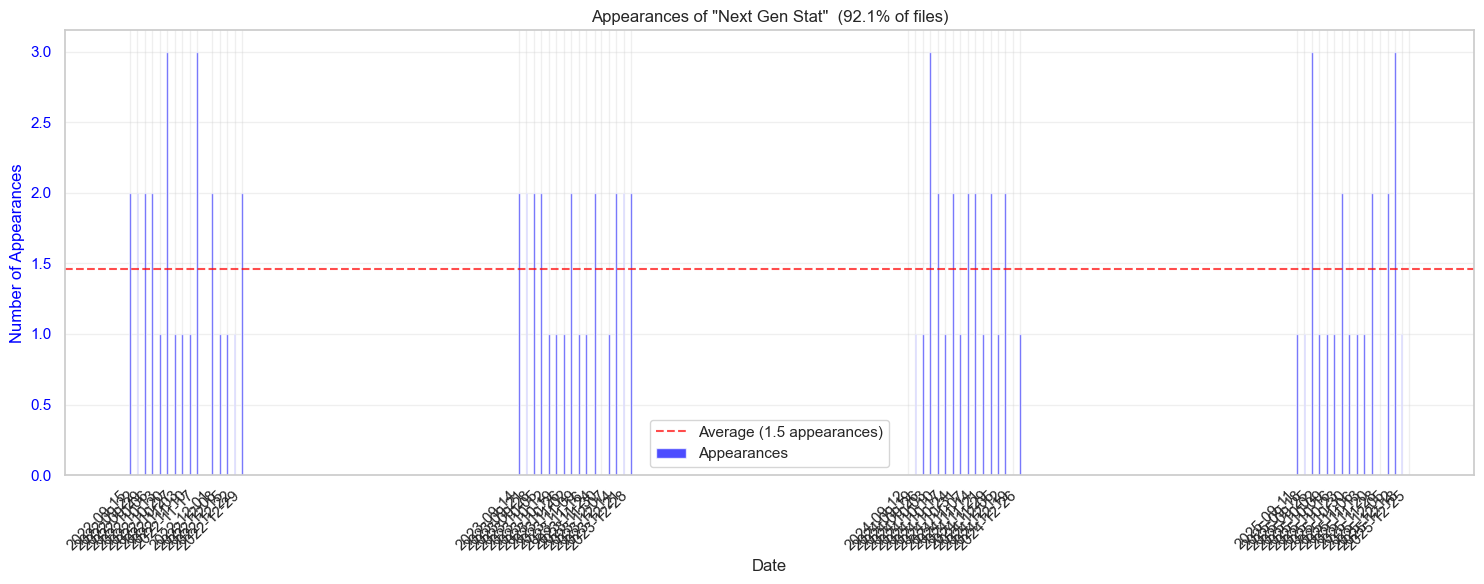


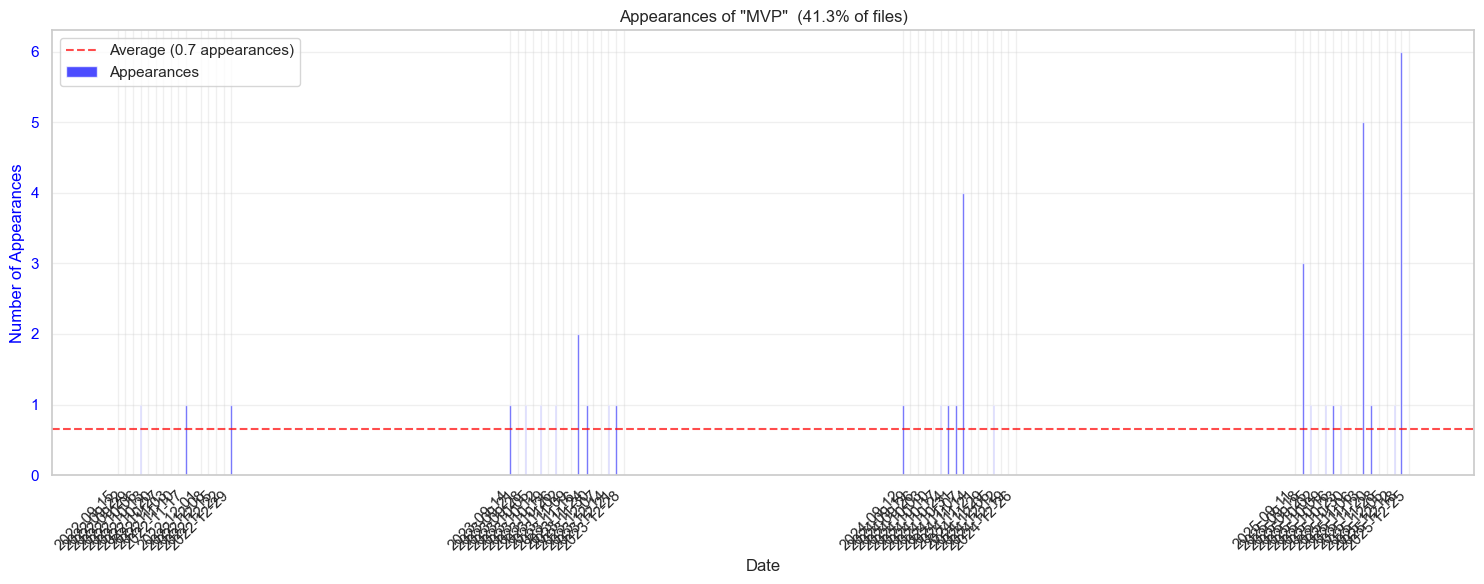


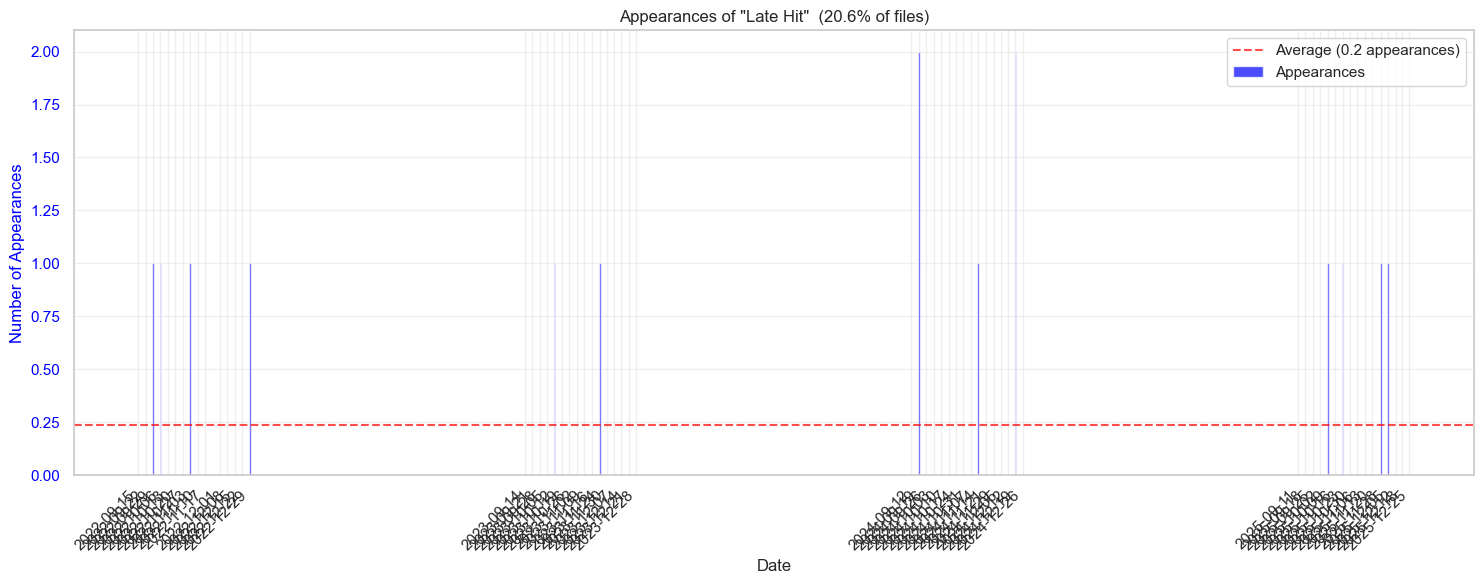


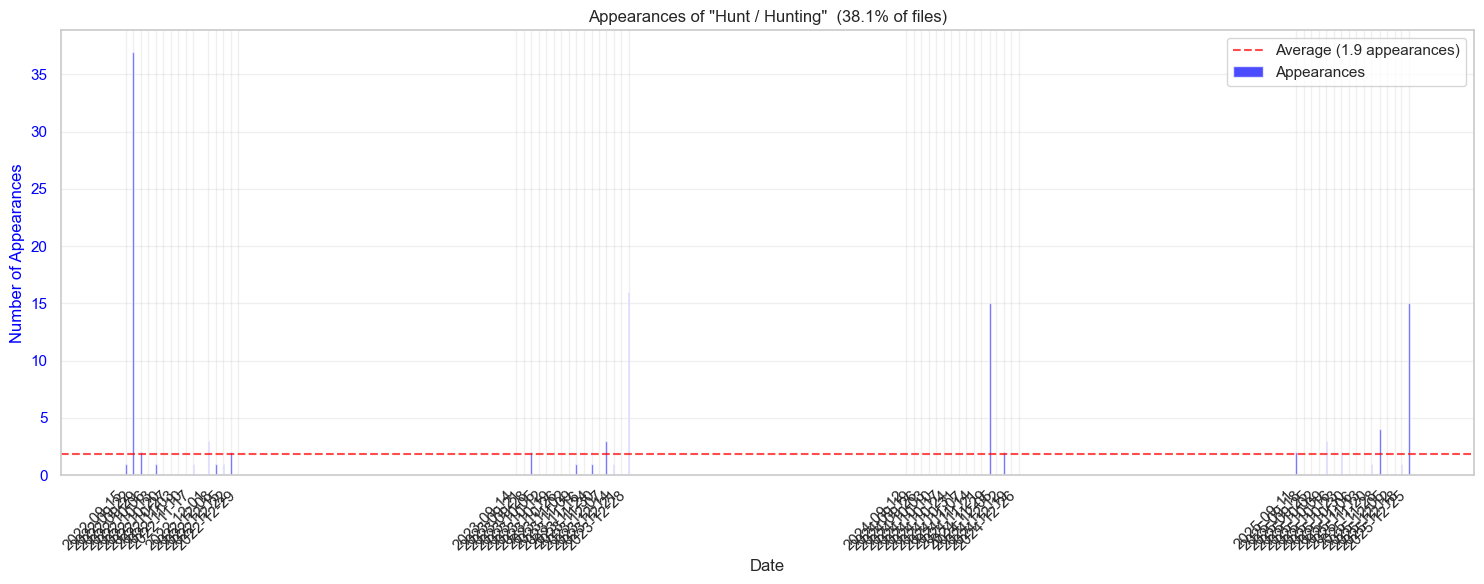


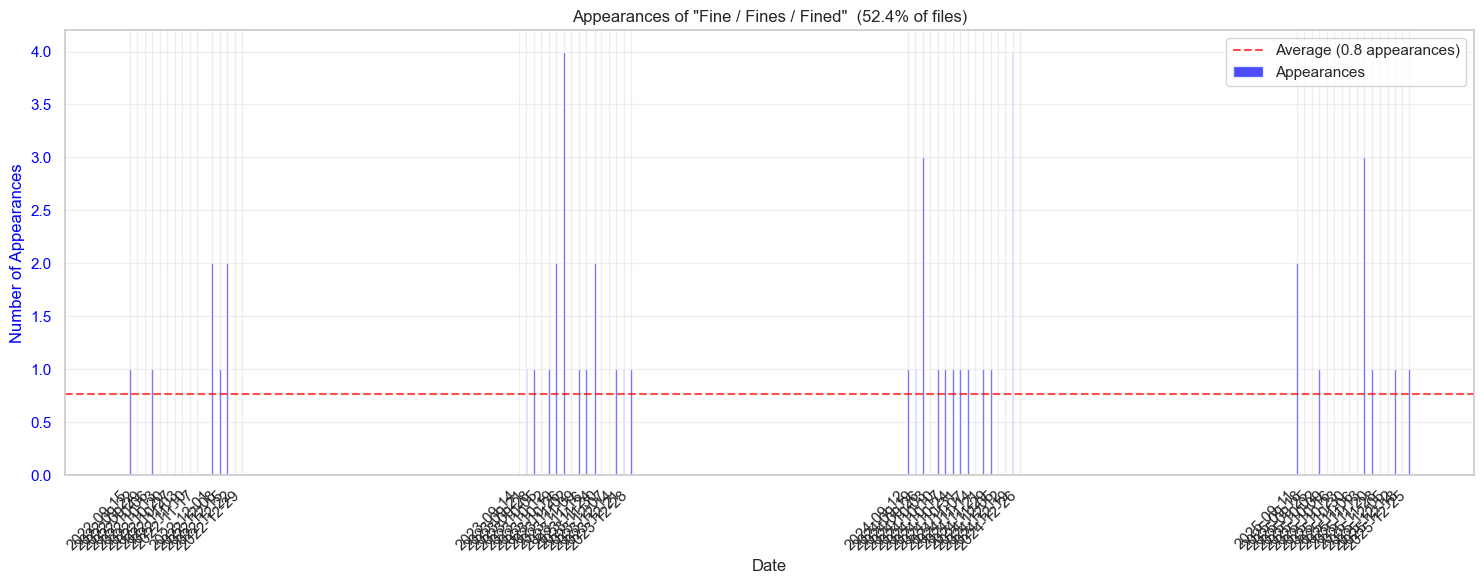


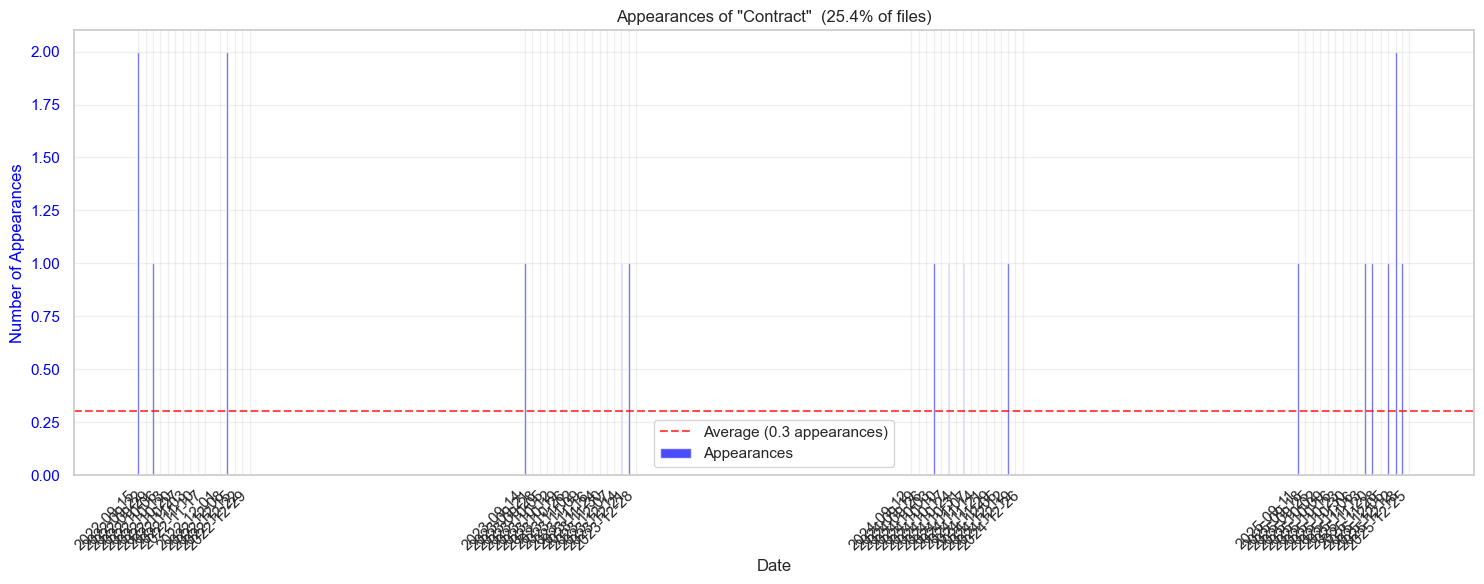


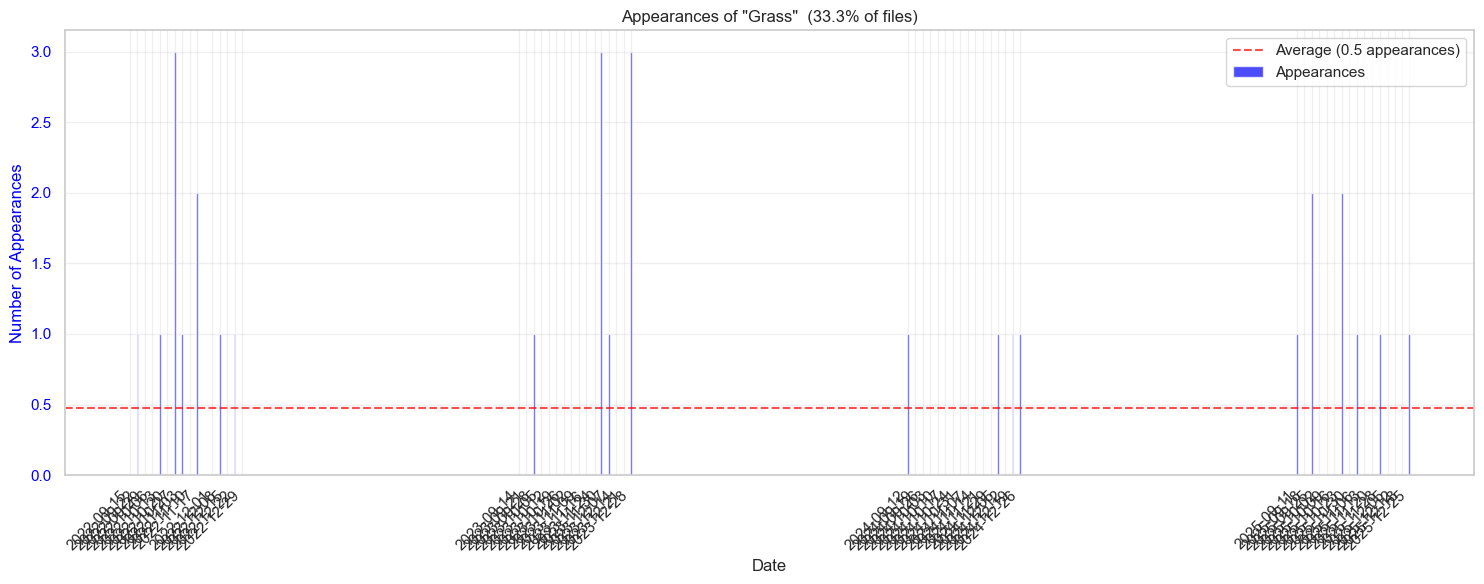


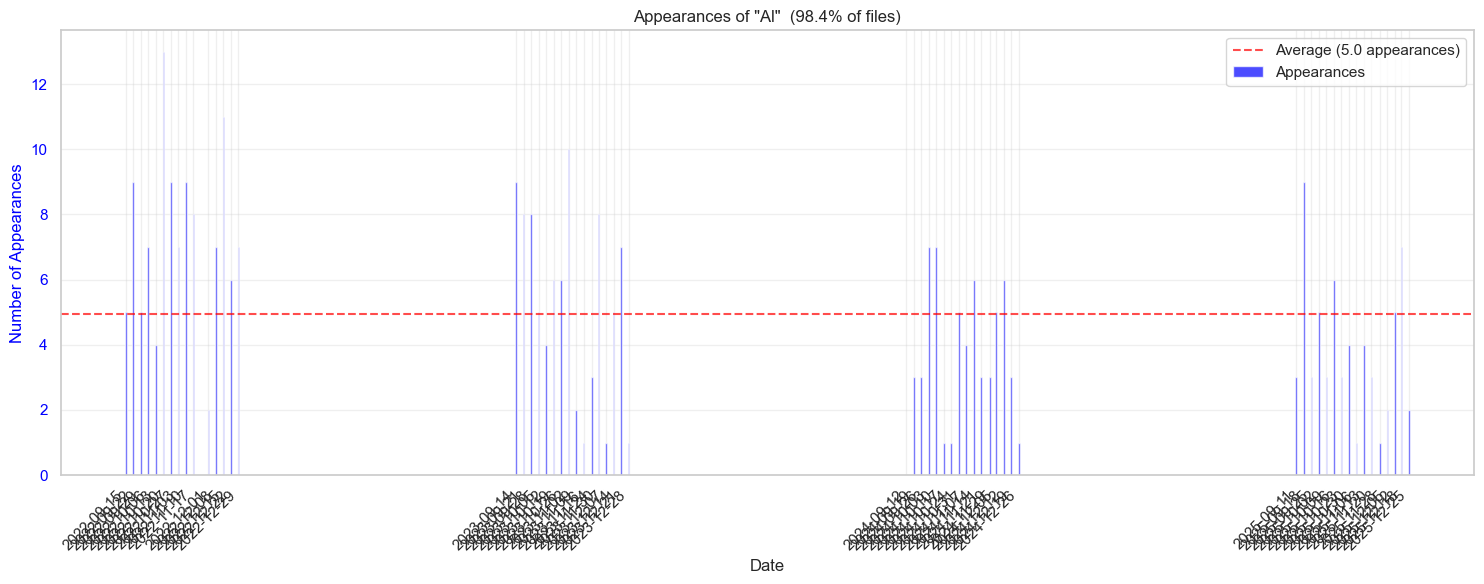


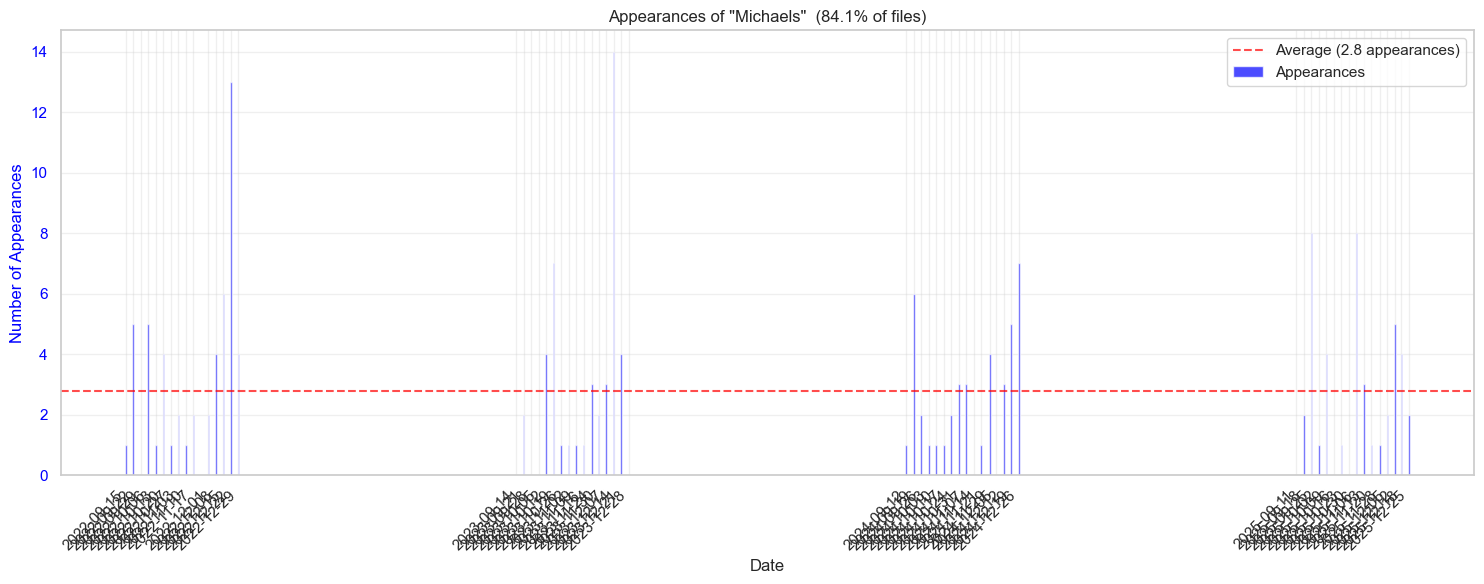


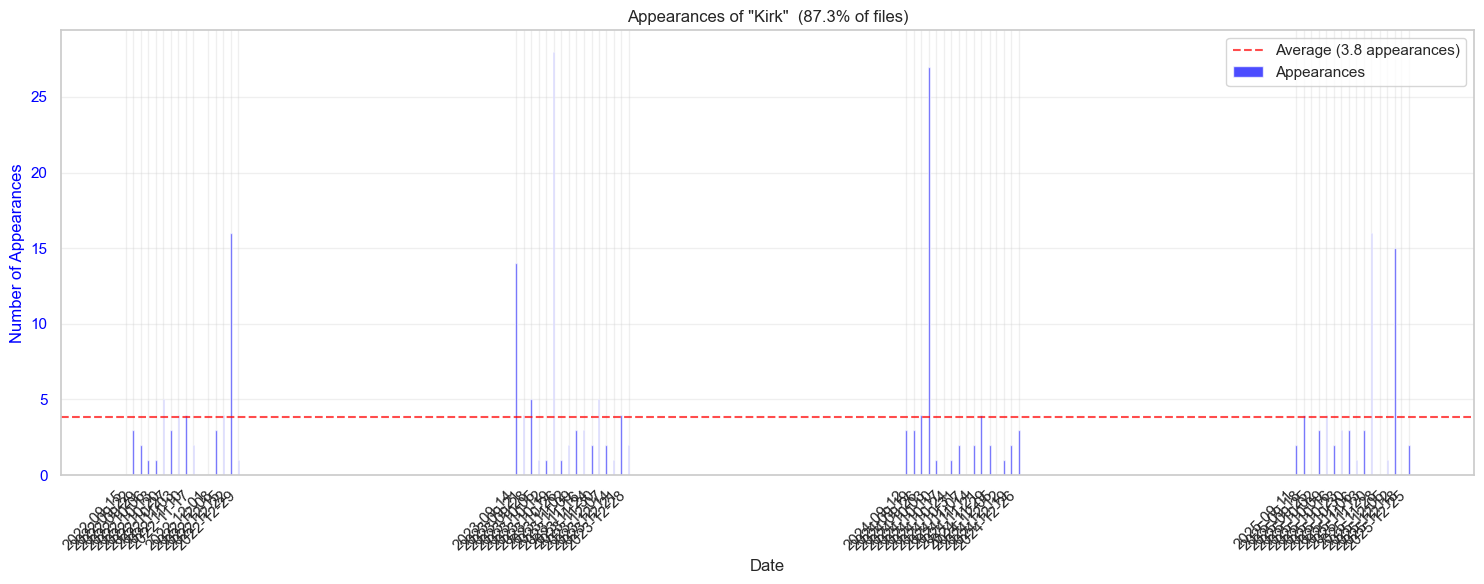


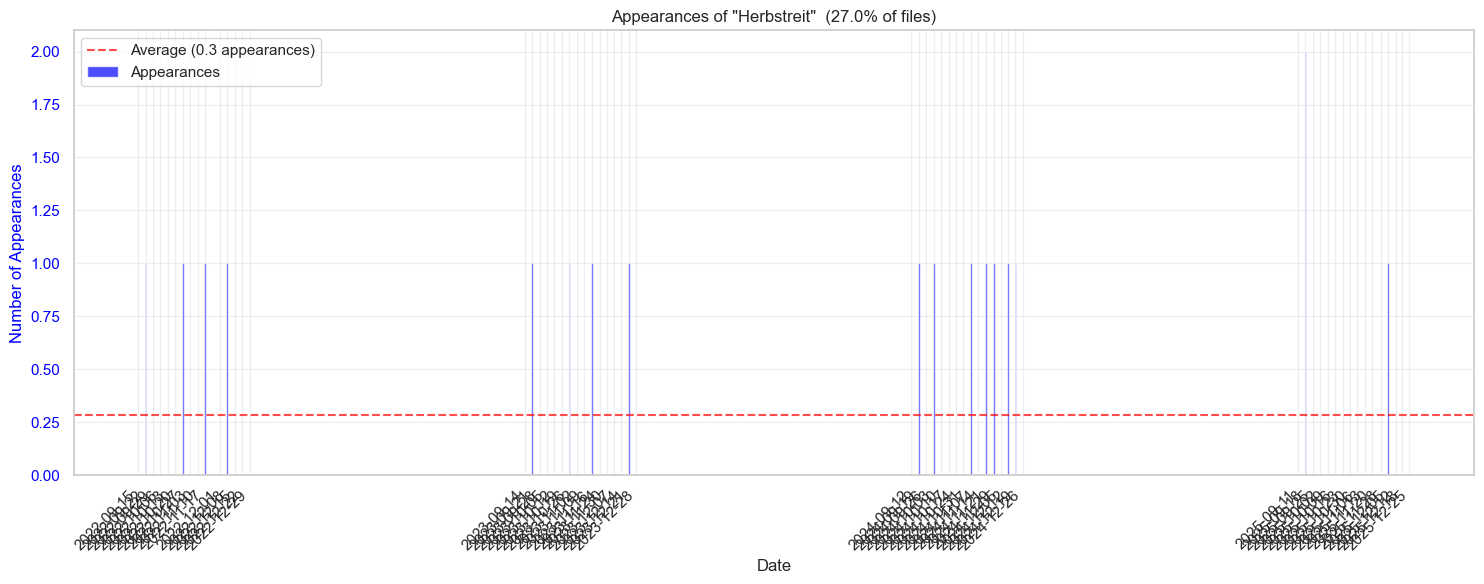


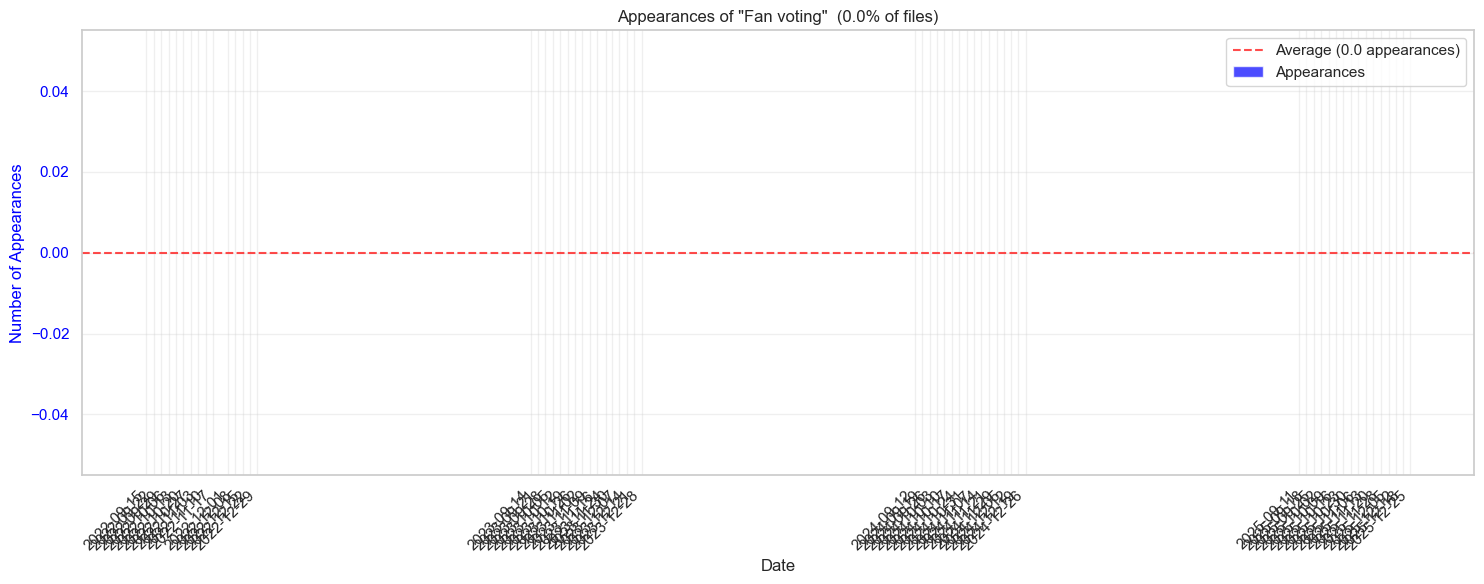


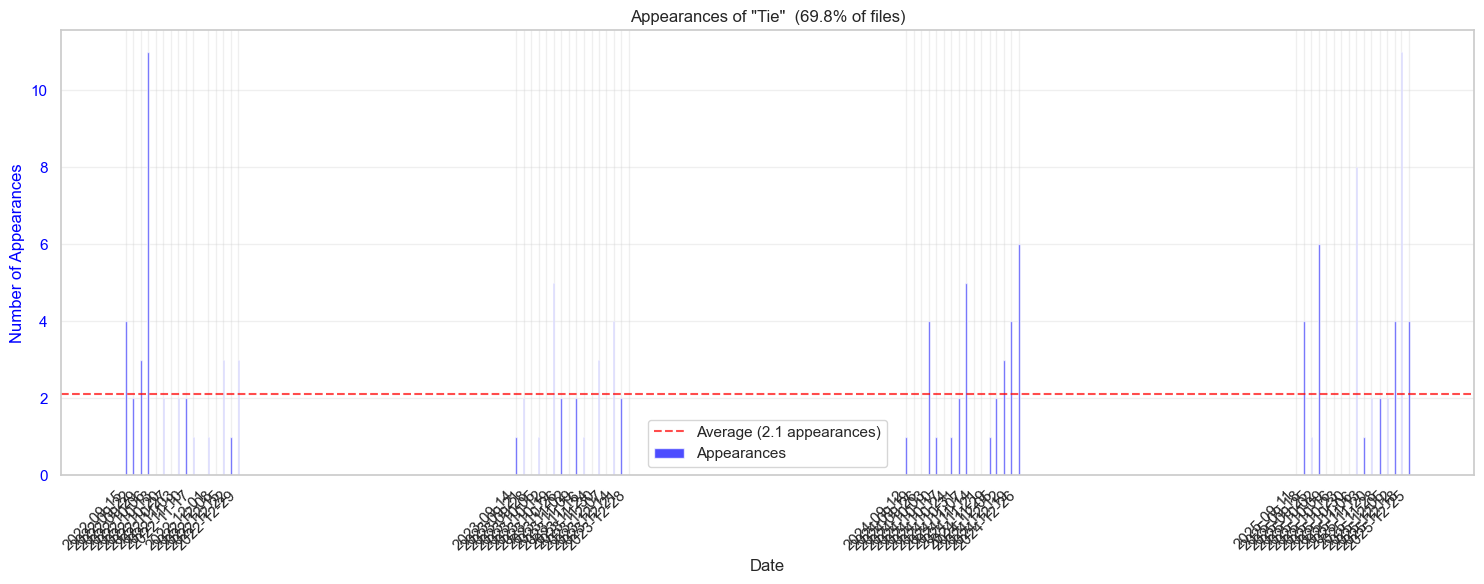

In [ ]:
from src.phrase_analysis import plot_phrases_individual_all
plot_phrases_individual_all(df_tnf, phrases=SEARCH_PHRASES)

## Teams

In [21]:
teams_df = df[df['file'].str.contains(f'{away}|{home}', case=False, na=False)].reset_index(drop=True)
teams_df = teams_df.sort_values('date')
analyze_files_phrase_occurrences(teams_df, SEARCH_PHRASES)
teams_df_all = df[df['file'].str.contains(f'{away}|{home}', case=False, na=False)].reset_index(drop=True)

df_away = df[df['file'].str.contains(f'{away}', case=False, na=False)].reset_index(drop=True)
# df_away = df_away.sort_values('date')
df_home = df[df['file'].str.contains(f'at-{home}', case=False, na=False)].reset_index(drop=True)
# df_home = df_home.sort_values('date')
analyze_files_phrase_occurrences(df_away, SEARCH_PHRASES)
analyze_files_phrase_occurrences(df_home, SEARCH_PHRASES)

Found 9 matching files:

  2022-10-13_commanders-at-bears.txt
  2022-11-17_titans-at-packers.txt
  2023-09-28_lions-at-packers.txt
  2023-10-05_bears-at-commanders.txt
  2023-11-09_panthers-at-bears.txt
  2024-12-05_packers-at-lions.txt
  2024-12-26_seahawks-at-bears.txt
  2025-09-11_commanders-at-packers.txt
  2025-11-28_bears-at-eagles.txt


Phrase occurrences across selected files (sorted by total occurrences):


/Users/jstenger/Documents/repos/kalshi-research/src/phrase_analysis.py:783: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phrase_rows['Total'] = phrase_rows[sort_columns].sum(axis=1)


,2022-10-13_commanders-at-bears.txt,2022-11-17_titans-at-packers.txt,2023-09-28_lions-at-packers.txt,2023-10-05_bears-at-commanders.txt,2023-11-09_panthers-at-bears.txt,2024-12-05_packers-at-lions.txt,2024-12-26_seahawks-at-bears.txt,2025-09-11_commanders-at-packers.txt,2025-11-28_bears-at-eagles.txt,Average
Word Count,16137,18551,17873,17982,17420,19257,15826,19562,17900,17834.222222
Rodgers,2,90,9,0,0,0,0,7,0,12.000000
Safety,3,20,14,22,5,13,6,12,7,11.333333
Al,4,8,8,5,2,5,1,3,1,4.111111
Trade / Traded,2,1,6,5,5,5,1,7,1,3.666667
Wind / Windy,2,2,0,3,3,2,2,2,12,3.111111
Kirk,1,2,5,1,3,0,3,2,0,1.888889
Soldier,5,0,0,0,2,0,6,0,3,1.777778
Record,1,0,1,0,4,2,4,2,1,1.666667
Tie,0,1,0,1,2,2,6,0,2,1.555556



Summary:
Total files processed: 9
Total word count: 160,508
Found 4 matching files:

  2024-12-05_packers-at-lions.txt
  2023-09-28_lions-at-packers.txt
  2022-11-17_titans-at-packers.txt
  2025-09-11_commanders-at-packers.txt


Phrase occurrences across selected files (sorted by total occurrences):


/Users/jstenger/Documents/repos/kalshi-research/src/phrase_analysis.py:783: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phrase_rows['Total'] = phrase_rows[sort_columns].sum(axis=1)


,2024-12-05_packers-at-lions.txt,2023-09-28_lions-at-packers.txt,2022-11-17_titans-at-packers.txt,2025-09-11_commanders-at-packers.txt,Average
Word Count,19257,17873,18551,19562,18810.750000
Rodgers,0,9,90,7,26.500000
Safety,13,14,20,12,14.750000
Al,5,8,8,3,6.000000
Trade / Traded,5,6,1,7,4.750000
Kirk,0,5,2,2,2.250000
Next Gen Stat,1,2,3,1,1.750000
Schedule,3,2,1,1,1.750000
Rival / Rivalry,2,0,3,1,1.500000
No Good,0,1,0,5,1.500000



Summary:
Total files processed: 4
Total word count: 75,243
Found 3 matching files:

  2023-11-09_panthers-at-bears.txt
  2022-10-13_commanders-at-bears.txt
  2024-12-26_seahawks-at-bears.txt


Phrase occurrences across selected files (sorted by total occurrences):


/Users/jstenger/Documents/repos/kalshi-research/src/phrase_analysis.py:783: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phrase_rows['Total'] = phrase_rows[sort_columns].sum(axis=1)


,2023-11-09_panthers-at-bears.txt,2022-10-13_commanders-at-bears.txt,2024-12-26_seahawks-at-bears.txt,Average
Word Count,17420,16137,15826,16461.000000
Safety,5,3,6,4.666667
Soldier,2,5,6,4.333333
Michaels,1,1,7,3.000000
Record,4,1,4,3.000000
Trade / Traded,5,2,1,2.666667
Tie,2,0,6,2.666667
Al,2,4,1,2.333333
Wind / Windy,3,2,2,2.333333
Kirk,3,1,3,2.333333



Summary:
Total files processed: 3
Total word count: 49,383


## Turf

In [ ]:
grass_fields = (
    'at-chiefs|chiefs.txt|'
    'at-commanders|commanders.txt|'
    'at-football-team|football-team.txt|'
    'at-redskins|redskins.txt|'
    'at-cardinals|cardinals.txt|'
    'at-ravens|ravens.txt|'
    'at-browns|browns.txt|'
    'at-broncos|broncos.txt|'
    'at-packers|packers.txt|'
    'at-jaguars|jaguars.txt|'
    'at-raiders|raiders.txt|'
    'at-dolphins|dolphins.txt|'
    'at-eagles|eagles.txt|'
    'at-steelers|steelers.txt|'
    'at-49ers|49ers.txt|'
    'at-bears|bears.txt'
    'at-buccaneers|buccaneers.txt'
)

turf_fields = (
    'at-falcons|falcons.txt|'
    'at-bills|bills.txt|'
    'at-bengals|bengals.txt|'
    'at-cowboys|cowboys.txt|'
    'at-lions|lions.txt|'
    'at-texans|texans.txt|'
    'at-colts|colts.txt|'
    'at-chargers|chargers.txt|'
    'at-rams|rams.txt|'
    'at-vikings|vikings.txt|'
    'at-patriots|patriots.txt|'
    'at-saints|saints.txt|'
    'at-giants|giants.txt|'
    'at-jets|jets.txt|'
    'at-seahawks|seahawks.txt'
    'at-titans|titans.txt'
    'at-panthers|panthers.txt'
)

grass_df = df_combined[df_combined['file'].str.contains(grass_fields, case=False, na=False)]
turf_df = df_combined[df_combined['file'].str.contains(turf_fields, case=False, na=False)]
mnf_grass = df_mnf[df_mnf['file'].str.contains(grass_fields, case=False, na=False)]
mnf_turf = df_mnf[df_mnf['file'].str.contains(turf_fields, case=False, na=False)]
snf_grass = df_snf[df_snf['file'].str.contains(grass_fields, case=False, na=False)]
snf_turf = df_snf[df_snf['file'].str.contains(turf_fields, case=False, na=False)]
tnf_grass = df_tnf[df_tnf['file'].str.contains(grass_fields, case=False, na=False)]
tnf_turf = df_tnf[df_tnf['file'].str.contains(turf_fields, case=False, na=False)]


In [ ]:
# grass_all_df = nfl_recent[nfl_recent['file'].str.contains(grass_fields, case=False, na=False)]
# turf_all_df = nfl_recent[nfl_recent['file'].str.contains(turf_fields, case=False, na=False)]

In [ ]:
get_per_appearance_frequency({ 'turf': turf_df, 'grass': grass_df, 'mnf turf': mnf_turf, 'mnf grass': mnf_grass, 'snf turf': snf_turf, 'snf grass': snf_grass, 'tnf turf': tnf_turf, 'tnf grass': tnf_grass}, {'Turf': 't', 'Grass': 'g'})

Percentage of Appearances Containing Each Phrase:


,turf,grass,mnf turf,mnf grass,snf turf,snf grass,tnf turf,tnf grass
# of files,101.00,110.00,35.00,38.00,36.00,40.00,30.00,32.00
Average word count,18439.46,18191.04,17725.83,17688.32,18710.00,18408.97,18947.37,18515.59
Turf,50.50,30.91,77.14,36.84,33.33,20.00,40.00,37.50
Grass,17.82,38.18,8.57,47.37,22.22,25.00,23.33,43.75


### Previous games

In [ ]:
old_phrases = get_phrases("KXNFLMENTION-25OCT06")
old_search_phrases = generate_regex_patterns(old_phrases)
df_mnf_oct6 = process_directory('../data-football/mnf/transcripts', old_search_phrases)
analyze_files_phrase_occurrences(df_mnf_oct6[df_mnf_oct6['file'].str.contains('2025-10-06', case=False, na=False)], old_search_phrases)

Categories found in directory:


KeyError: 'file'

## Poisson Predictions

In [ ]:
# Calculate predictions from different data sources
length = df['text_length'].mean()
print("using length: ", length)
predictions_all = calculate_poisson_predictions(df, length, SEARCH_PHRASES)

print("Predictions based on all appearances:")
display(format_prediction_table(predictions_all))


using length:  18778.90322580645
Predictions based on all appearances:


,Phrase,Expected,Historical Rate,Total Historical,P(≥1)
8,Safety,10.64,0.567,660,100.0%
22,Al,5.00,0.266,310,99.3%
6,Superbowl / Super Bowl,4.98,0.265,309,99.3%
24,Kirk,3.86,0.205,239,97.9%
0,Wind / Windy,2.95,0.157,183,94.8%
23,Michaels,2.81,0.149,174,94.0%
5,Trade / Traded,2.63,0.140,163,92.8%
27,Tie,2.08,0.111,129,87.5%
11,Record,1.95,0.104,121,85.8%
7,Schedule,1.74,0.093,108,82.5%


## Negative Binomial 

In [ ]:
print("using length: ", length:=df['text_length'].mean())

print("Negative Binomial Predictions based on all appearances:")
nb_predictions = calculate_negative_binomial_predictions(df, length, SEARCH_PHRASES)
display(format_prediction_table(nb_predictions))



using length:  18778.90322580645
Negative Binomial Predictions based on all appearances:


,Phrase,Expected,Dispersion (r),Sample Variance,P(≥1),P(≥3)
8,Safety,10.64,5.91,29.81,99.8%,0.970
22,Al,5.00,7.40,8.38,97.8%,0.802
6,Superbowl / Super Bowl,4.98,4.82,10.14,96.7%,0.769
24,Kirk,3.86,0.57,30.09,68.8%,0.428
0,Wind / Windy,2.95,0.91,12.49,73.2%,0.409
23,Michaels,2.81,1.34,8.70,78.0%,0.422
5,Trade / Traded,2.63,2.73,5.16,84.1%,0.435
27,Tie,2.08,1.51,4.94,73.0%,0.321
11,Record,1.95,3.14,3.16,78.1%,0.308
7,Schedule,1.74,2.94,2.77,74.6%,0.263


## Recent Usage in context

In [ ]:
get_recent_contexts_all(df, {'Hunt / Hunting': SEARCH_PHRASES['Hunt / Hunting']}, n=1000)



=== Recent usage of 'Hunt / Hunting' ===

Title: 2025-12-18_rams-at-seahawks.txt
Date: 2025-12-18 (transcripts)
Context: ... again now the remaining schedules told you about the importance of this one. Rams go to Atlanta next week, have the Cards at home. Hawks go to the Panthers next week. Still they are very much in the hunt in the NFC south at the Niners and the Niners at the Colts. Then the Bears at home and the Seahawks. It's came on now it is. Don't forget Kobe Bryant is out try. Okada is in in his spot for the 22 ya...

Title: 2025-11-28_bears-at-eagles.txt
Date: 2025-11-28 (transcripts)
Context: ... teams or one-on-one matchups, this offensive line is in sync and playing well. Second and one, Monongai is the back. Take it to him. And then it's picked off. Intercepted to the 35-yard line, Jaylix Hunt. And the Eagles back in business. Now pull me once, shame on you, pull me twice, shame on me. They've tried that screen off to the left a few times and it's worked. And this time J

## Per-Speech Frequencies


In [ ]:
get_per_appearance_frequency({'teams': teams_df, 'teams-all': teams_df_all, 'tnf': df_tnf, 'snf': df_snf,  'mnf': df_mnf, 'turf': turf_df, 'grass': grass_df, 'no Hunt': no_hunt_df}, SEARCH_PHRASES, show_confidence_interval=True)


Percentage of Appearances Containing Each Phrase (with 95% Confidence Intervals):


,teams,teams-all,tnf,snf,mnf,turf,grass,no Hunt
# of files,7.0,33.0,62.0,74.0,70.0,99.0,106.0,44.0
Average word count,18873.57,18407.79,18778.9,18534.93,17749.3,18457.17,18217.6,19082.16
Record,100.0% (64.6-100.0%),78.79% (62.2-89.3%),82.26% (71.0-89.8%),78.38% (67.7-86.2%),88.57% (79.0-94.1%),83.84% (75.3-89.8%),82.08% (73.7-88.2%),77.27% (63.0-87.2%)
Michaels,100.0% (64.6-100.0%),72.73% (55.8-84.9%),83.87% (72.8-91.0%),77.03% (66.3-85.1%),61.43% (49.7-72.0%),80.81% (72.0-87.4%),66.98% (57.6-75.2%),88.64% (76.0-95.0%)
Al,100.0% (64.6-100.0%),36.36% (22.2-53.4%),98.39% (91.4-99.7%),27.03% (18.2-38.1%),21.43% (13.4-32.4%),49.49% (39.9-59.2%),43.4% (34.4-52.9%),100.0% (92.0-100.0%)
Superbowl / Super Bowl,100.0% (64.6-100.0%),96.97% (84.7-99.5%),95.16% (86.7-98.3%),95.95% (88.7-98.6%),87.14% (77.3-93.1%),89.9% (82.4-94.4%),95.28% (89.4-98.0%),93.18% (81.8-97.7%)
Trade / Traded,85.71% (48.7-97.4%),78.79% (62.2-89.3%),82.26% (71.0-89.8%),74.32% (63.3-82.9%),88.57% (79.0-94.1%),79.8% (70.8-86.5%),83.96% (75.8-89.7%),81.82% (68.0-90.5%)
Fine / Fines / Fined,85.71% (48.7-97.4%),45.45% (29.8-62.0%),51.61% (39.4-63.6%),64.86% (53.5-74.8%),44.29% (33.2-55.9%),56.57% (46.7-65.9%),51.89% (42.5-61.2%),54.55% (40.1-68.3%)
Safety,85.71% (48.7-97.4%),96.97% (84.7-99.5%),98.39% (91.4-99.7%),100.0% (95.1-100.0%),100.0% (94.8-100.0%),98.99% (94.5-99.8%),100.0% (96.5-100.0%),97.73% (88.2-99.6%)
Next Gen Stat,85.71% (48.7-97.4%),36.36% (22.2-53.4%),93.55% (84.6-97.5%),40.54% (30.1-51.9%),2.86% (0.8-9.8%),44.44% (35.0-54.3%),42.45% (33.5-52.0%),95.45% (84.9-98.7%)


In [ ]:
exclude_teams = ['browns', 'chiefs', 'dolphins', 'panthers', 'eagles']
# Assuming your dataframe has a "file" or "teams" column containing team names in the filename like "..._browns..." etc.
no_hunt_df = df[~df['file'].str.contains('|'.join(exclude_teams), case=False, na=False)]

